In [26]:
import torch
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from safetensors.torch import load_file
import matplotlib.pyplot as plt
import json

In [5]:
import torch
import sys
import subprocess

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("Torch CUDA runtime tag:", torch.version.cuda)
print("torch.cuda.is_available():", torch.cuda.is_available())

try:
    out = subprocess.check_output(["nvidia-smi", "-L"], text=True)
    print("nvidia-smi detected GPUs:")
    print(out)
except Exception as e:
    print("nvidia-smi check failed:", e)

Python: 3.13.15 | packaged by conda-forge | (main, Aug 10 2026, 13:05:01) [GCC 14.4.0]
Torch: 2.6.0+cu124
Torch CUDA runtime tag: 12.4
torch.cuda.is_available(): True
nvidia-smi detected GPUs:
GPU 0: NVIDIA L4 (UUID: GPU-9774d39d-3704-9391-3d24-c14e1d8dd9b0)



In [3]:
device = torch.device('cuda')

In [4]:
tensors = load_file("/workspace/results/patient_graphs.safetensors")["patient_graphs"].to(device)

In [6]:
with open("/workspace/results/patient_graphs_meta.json", "r") as f:
    sample_ids = json.load(f)["sample_ids"]

In [8]:
pheno_df = pd.read_parquet("/workspace/data/GSE111629_pheno_data.parquet")

In [9]:
if pheno_df.index.name != "Sample_Name":
    pheno_df = pheno_df.set_index("Sample_Name")
pheno_aligned = pheno_df.loc[sample_ids]

In [14]:
y = torch.tensor(pd.get_dummies(pheno_aligned['Sample_Group']).values.astype(np.float32), device=device)
cell_cols = ['CD8T', 'CD4T', 'NK', 'Bcell', 'Mono', 'Gran']
u = torch.tensor(pheno_aligned[cell_cols].values.astype(np.float32), device=device)

In [18]:
y_label = torch.argmax(y, dim=1)  # collapse one-hot back to a single 0/1 label for sklearn/XGBoost
y_cpu = y_label.cpu().numpy()
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [28]:
roc_aucs = []
pr_aucs = []
roc_curves = []
pr_curves = []

In [30]:
for fold, (train_idx, test_idx) in enumerate(skf.split(np.zeros(len(y_cpu)), y_cpu)):
    
    # --- A. Isolate Fold Data (On GPU) ---
    X_train, X_test = tensors[train_idx], tensors[test_idx]
    y_train, y_test = y_label[train_idx], y_label[test_idx]
    u_train, u_test = u[train_idx], u[test_idx]
    
    # --- B. GPU Unsupervised Feature Selection ---
    # Calculated instantly on CUDA cores
    train_variances = X_train[:, :, 0].var(dim=0) 
    top_5k_indices = torch.topk(train_variances, 5000).indices
    
    # --- C. Slice and Flatten Tensors ---
    X_train_sub = X_train[:, top_5k_indices, :]
    X_test_sub = X_test[:, top_5k_indices, :]
    
    X_train_flat = X_train_sub.reshape(X_train_sub.shape[0], -1)
    X_test_flat = X_test_sub.reshape(X_test_sub.shape[0], -1)
    
    # --- D. Modality Integration ---
    X_train_final = torch.cat([X_train_flat, u_train], dim=1)
    X_test_final = torch.cat([X_test_flat, u_test], dim=1)
    
    # --- E. Handle Class Imbalance ---
    neg_count = (y_train == 0).sum().item()
    pos_count = (y_train == 1).sum().item()
    scale_weight = neg_count / pos_count
    
    # --- F. Train XGBoost Natively on GPU ---
    clf = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.05,
        scale_pos_weight=scale_weight,
        eval_metric='logloss',
        random_state=42,
        tree_method='hist', # Enables modern XGBoost histogram algorithm
        device='cuda'       # Executes directly on your NVIDIA GPU
    )
    
    # XGBoost accepts PyTorch CUDA tensors natively!
    clf.fit(X_train_final, y_train)
    
    # --- G. Evaluate ---
    y_pred_proba = clf.predict_proba(X_test_final)[:, 1]
    
    # Scikit-learn metrics require CPU numpy arrays
    fold_roc = roc_auc_score(y_test.cpu().numpy(), y_pred_proba)
    fold_pr = average_precision_score(y_test.cpu().numpy(), y_pred_proba)
    
    roc_aucs.append(fold_roc)
    pr_aucs.append(fold_pr)
    
    fpr, tpr, _ = roc_curve(y_test.cpu().numpy(), y_pred_proba)
    precision, recall, _ = precision_recall_curve(y_test.cpu().numpy(), y_pred_proba)
    roc_curves.append((fpr, tpr))
    pr_curves.append((precision, recall))
    
    print(f"Fold {fold+1} | ROC AUC: {fold_roc:.4f} | PR AUC: {fold_pr:.4f}")

Fold 1 | ROC AUC: 0.6546 | PR AUC: 0.6933
Fold 2 | ROC AUC: 0.5599 | PR AUC: 0.6502
Fold 3 | ROC AUC: 0.6860 | PR AUC: 0.7279
Fold 4 | ROC AUC: 0.6436 | PR AUC: 0.6909
Fold 5 | ROC AUC: 0.7131 | PR AUC: 0.7735


In [31]:
print("-" * 30)
print(f"Mean ROC AUC: {np.mean(roc_aucs):.4f} ± {np.std(roc_aucs):.4f}")
print(f"Mean PR AUC:  {np.mean(pr_aucs):.4f} ± {np.std(pr_aucs):.4f}")

------------------------------
Mean ROC AUC: 0.6515 ± 0.0519
Mean PR AUC:  0.7072 ± 0.0413


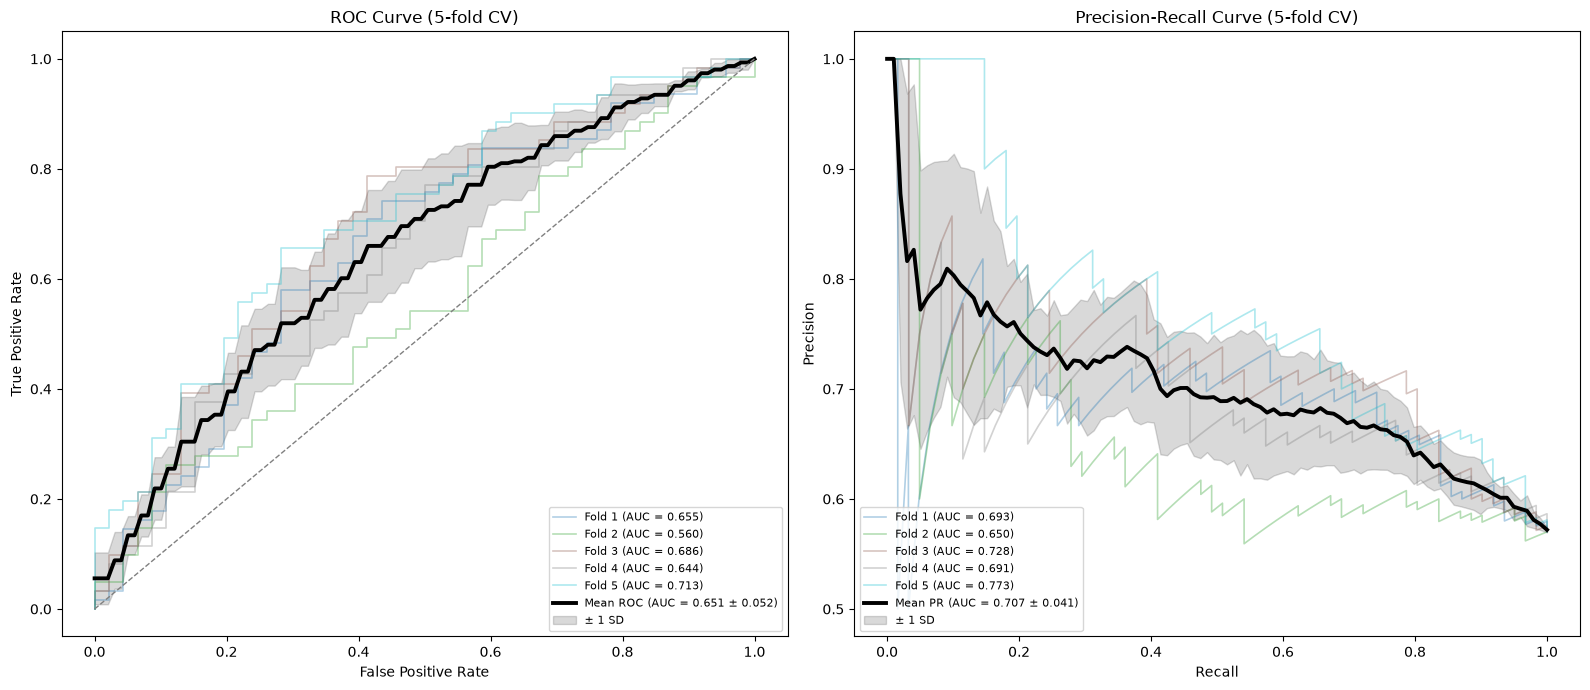

In [33]:
mean_fpr = np.linspace(0, 1, 100)
mean_recall = np.linspace(0, 1, 100)
colors = plt.cm.tab10(np.linspace(0, 1, len(roc_curves)))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- ROC ---
tprs_interp = []
for i, (fpr, tpr) in enumerate(roc_curves):
    axes[0].plot(fpr, tpr, color=colors[i], alpha=0.35, lw=1.2,
                 label=f"Fold {i+1} (AUC = {roc_aucs[i]:.3f})")
    tprs_interp.append(np.interp(mean_fpr, fpr, tpr))

tprs_interp = np.array(tprs_interp)
mean_tpr = tprs_interp.mean(axis=0)
mean_tpr[-1] = 1.0
std_tpr = tprs_interp.std(axis=0)

axes[0].plot(mean_fpr, mean_tpr, color="black", lw=2.8,
             label=f"Mean ROC (AUC = {np.mean(roc_aucs):.3f} ± {np.std(roc_aucs):.3f})")
axes[0].fill_between(mean_fpr, np.clip(mean_tpr - std_tpr, 0, 1), np.clip(mean_tpr + std_tpr, 0, 1),
                      color="black", alpha=0.15, label="± 1 SD")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve (5-fold CV)")
axes[0].legend(loc="lower right", fontsize=8)

# --- Precision-Recall ---
precisions_interp = []
for i, (precision, recall) in enumerate(pr_curves):
    axes[1].plot(recall, precision, color=colors[i], alpha=0.35, lw=1.2,
                 label=f"Fold {i+1} (AUC = {pr_aucs[i]:.3f})")
    order = np.argsort(recall)
    precisions_interp.append(np.interp(mean_recall, recall[order], precision[order]))

precisions_interp = np.array(precisions_interp)
mean_precision = precisions_interp.mean(axis=0)
std_precision = precisions_interp.std(axis=0)

axes[1].plot(mean_recall, mean_precision, color="black", lw=2.8,
             label=f"Mean PR (AUC = {np.mean(pr_aucs):.3f} ± {np.std(pr_aucs):.3f})")
axes[1].fill_between(mean_recall, np.clip(mean_precision - std_precision, 0, 1), np.clip(mean_precision + std_precision, 0, 1),
                      color="black", alpha=0.15, label="± 1 SD")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve (5-fold CV)")
axes[1].legend(loc="lower left", fontsize=8)

plt.tight_layout()

save_path = "/workspace/results/peg1_ROC_PR_AUC.png"
plt.savefig(save_path, dpi=300)

plt.show()

In [23]:
%conda install shap -y

2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.5.3
    latest version: 26.7.1

Please update conda by running

    $ conda self update



## Package Plan ##

  environment location: /opt/conda/envs/rapids-env

  added / updated specs:
    - shap


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    shap-0.51.0                |cpu_py313h80a60be_1         3.8 MB
    slicer-0.0.8               |  py313h77c3f3f_2          44 KB
    ------------------------------------------------------------
                                           Total:         3.9 MB

The following NEW packages will be INSTALLED:

  shap               pkgs/main/linux-64::shap-0.51.0-cpu_py313h80a60be_1 
  slicer             pkgs/main/linux-64::slicer-0.0.8-py313h77c3f3f

https://pmc.ncbi.nlm.nih.gov/articles/PMC4362250/
PDGF-B encodes PDGF-BB protein

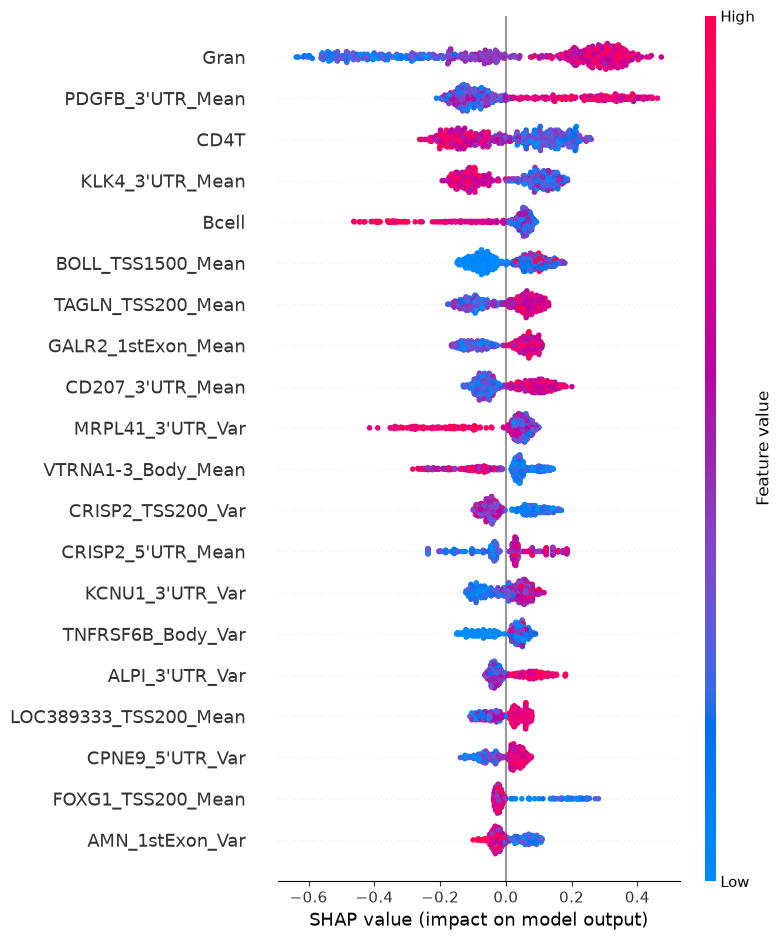

In [35]:
import shap
import json
import xgboost as xgb
import matplotlib.pyplot as plt

# 1. Map the 5,000 top indices back to string names
with open("/workspace/results/patient_graphs_meta.json", "r") as f:
    ordered_regions = json.load(f)["ordered_regions"]

# Recalculate top 5k on the full dataset to match the global model
global_variances = tensors[:, :, 0].var(dim=0)
top_5k_indices = torch.topk(global_variances, 5000).indices

# Generate the 10,006 feature names
hvg_names = [ordered_regions[i.item()] for i in top_5k_indices]
feature_names = (
    [f"{name}_Mean" for name in hvg_names] + 
    [f"{name}_Var" for name in hvg_names] + 
    ['CD8T', 'CD4T', 'NK', 'Bcell', 'Mono', 'Gran']
)

# 2. Prepare the Global Matrix
X_sub = tensors[:, top_5k_indices, :]
X_flat = X_sub.reshape(X_sub.shape[0], -1)
# SHAP requires CPU numpy arrays for visualization
X_final = torch.cat([X_flat, u], dim=1).cpu().numpy() 
y_final = y.cpu().numpy()

# 3. Train the Global Explainer Model
clf = xgb.XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.05, 
    scale_pos_weight=scale_weight, eval_metric='logloss',
    random_state=42, tree_method='hist', device='cuda'
)
clf.fit(X_final, y_final)

# 1. Initialize the Explainer
explainer = shap.TreeExplainer(clf)
raw_shap_values = explainer.shap_values(X_final)

# 2. Intercept and format the SHAP output
# If SHAP returns a list [Controls_Array, PD_Array], grab the PD array
if isinstance(raw_shap_values, list):
    shap_values_2d = raw_shap_values[1]
# If SHAP returns a 3D array (samples, features, classes), slice the PD class
elif len(raw_shap_values.shape) == 3:
    shap_values_2d = raw_shap_values[:, :, 1]
# Otherwise, it's already a standard 2D array
else:
    shap_values_2d = raw_shap_values

# 3. Generate the correct Beeswarm Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_2d, 
    X_final, 
    feature_names=feature_names, 
    max_display=20,
    plot_type="dot",  # Explicitly forces the beeswarm layout
    show=False  # keep the figure open so savefig captures it
)

save_path = "/workspace/results/peg1_shap_beeswarm.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

In [51]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from safetensors.torch import load_file
import matplotlib.pyplot as plt
import json

# 1. Define the Neural Architecture
class MethylationMLP(nn.Module):
    def __init__(self, input_dim=10006):
        super(MethylationMLP, self).__init__()
        self.network = nn.Sequential(
            # Layer 1: Massive Compression & Normalization
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            
            # Layer 2: Feature Extraction
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Layer 3: Output Logit
            nn.Linear(128, 1)
        )
        
    def forward(self, x):
        return self.network(x)

# 2. Setup Device & Load Data directly into GPU VRAM
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

tensors = load_file("/workspace/results/patient_graphs.safetensors")["patient_graphs"].to(device)

with open("/workspace/results/patient_graphs_meta.json", "r") as f:
    sample_ids = json.load(f)["sample_ids"]

pheno_df = pd.read_parquet("/workspace/data/GSE111629_pheno_data.parquet")
if pheno_df.index.name != "Sample_Name":
    pheno_df = pheno_df.set_index("Sample_Name")
pheno_aligned = pheno_df.loc[sample_ids]

# Move targets and cell proportions to GPU
y = torch.tensor(pd.get_dummies(pheno_aligned['Sample_Group']).values.astype(np.float32), device=device)
cell_cols = ['CD8T', 'CD4T', 'NK', 'Bcell', 'Mono', 'Gran']
u = torch.tensor(pheno_aligned[cell_cols].values.astype(np.float32), device=device)

# 3. Setup Stratified K-Fold
y_label = torch.argmax(y, dim=1).float()  # collapse one-hot back to a single 0/1 label
y_cpu = y_label.cpu().numpy()
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Training Hyperparameters
epochs = 60
batch_size = 64
learning_rate = 1e-4

roc_aucs = []
pr_aucs = []
roc_curves = []
pr_curves = []
print(f"Starting GPU-Accelerated 5-Fold Stratified CV for PyTorch MLP on {device}...")

for fold, (train_idx, test_idx) in enumerate(skf.split(np.zeros(len(y_cpu)), y_cpu)):
    
    # --- A. Isolate Fold Data (CUDA) ---
    X_train, X_test = tensors[train_idx], tensors[test_idx]
    y_train, y_test = y_label[train_idx], y_label[test_idx]
    u_train, u_test = u[train_idx], u[test_idx]
    
    # --- B. GPU Unsupervised Feature Selection (NO LEAKAGE) ---
    train_variances = X_train[:, :, 0].var(dim=0) 
    top_5k_indices = torch.topk(train_variances, 5000).indices
    
    # --- C. Slice and Flatten ---
    X_train_sub = X_train[:, top_5k_indices, :]
    X_test_sub = X_test[:, top_5k_indices, :]
    
    X_train_flat = X_train_sub.reshape(X_train_sub.shape[0], -1)
    X_test_flat = X_test_sub.reshape(X_test_sub.shape[0], -1)
    
    # --- D. Modality Integration ---
    X_train_final = torch.cat([X_train_flat, u_train], dim=1)
    X_test_final = torch.cat([X_test_flat, u_test], dim=1)
    
    # --- E. Standardization (Strictly using train statistics) ---
    train_mean = X_train_final.mean(dim=0, keepdim=True)
    train_std = X_train_final.std(dim=0, keepdim=True)
    train_std[train_std == 0] = 1e-6 # Avoid division by zero
    
    X_train_scaled = (X_train_final - train_mean) / train_std
    X_test_scaled = (X_test_final - train_mean) / train_std
    
    # --- F. Create DataLoader ---
    train_dataset = TensorDataset(X_train_scaled, y_train.unsqueeze(1))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    
    # --- G. Initialize Model, Loss, & Optimizer ---
    model = MethylationMLP(input_dim=10006).to(device)
    
    # Handle Class Imbalance via Loss Weighting
    neg_count = (y_train == 0).sum()
    pos_count = (y_train == 1).sum()
    pos_weight = neg_count / pos_count
    
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-3)
    
    # --- H. Optimization Loop ---
    model.train()
    for epoch in range(epochs):
        for batch_x, batch_y in train_loader:
            optimizer.zero_grad()
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            optimizer.step()
            
    # --- I. Evaluation ---
    model.eval()
    with torch.no_grad():
        test_logits = model(X_test_scaled)
        # Apply sigmoid to extract probability predictions
        test_probs = torch.sigmoid(test_logits).squeeze(1).cpu().numpy()
        
    y_test_cpu = y_test.cpu().numpy()
    fold_roc = roc_auc_score(y_test_cpu, test_probs)
    fold_pr = average_precision_score(y_test_cpu, test_probs)
    
    roc_aucs.append(fold_roc)
    pr_aucs.append(fold_pr)
    fpr, tpr, _ = roc_curve(y_test_cpu, test_probs)
    precision, recall, _ = precision_recall_curve(y_test_cpu, test_probs)
    roc_curves.append((fpr, tpr))
    pr_curves.append((precision, recall))
    
    print(f"Fold {fold+1} | ROC AUC: {fold_roc:.4f} | PR AUC: {fold_pr:.4f}")

# 4. Final Summary
print("-" * 30)
print(f"Mean ROC AUC: {np.mean(roc_aucs):.4f} ± {np.std(roc_aucs):.4f}")
print(f"Mean PR AUC:  {np.mean(pr_aucs):.4f} ± {np.std(pr_aucs):.4f}")


Starting GPU-Accelerated 5-Fold Stratified CV for PyTorch MLP on cuda...
Fold 1 | ROC AUC: 0.7111 | PR AUC: 0.7561
Fold 2 | ROC AUC: 0.6761 | PR AUC: 0.7373
Fold 3 | ROC AUC: 0.7309 | PR AUC: 0.7595
Fold 4 | ROC AUC: 0.7741 | PR AUC: 0.7995
Fold 5 | ROC AUC: 0.8421 | PR AUC: 0.8716
------------------------------
Mean ROC AUC: 0.7468 ± 0.0572
Mean PR AUC:  0.7848 ± 0.0479


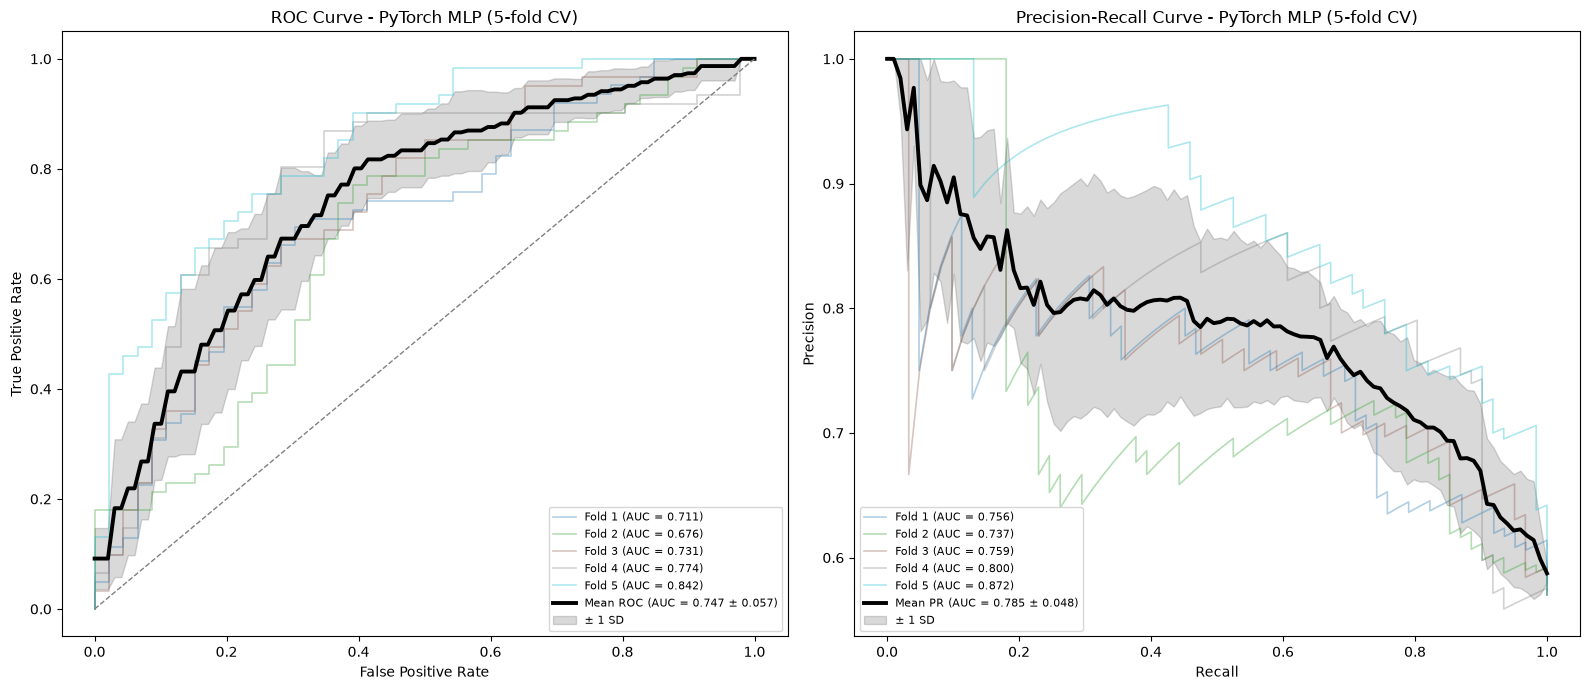

In [52]:
mean_fpr = np.linspace(0, 1, 100)
mean_recall = np.linspace(0, 1, 100)
colors = plt.cm.tab10(np.linspace(0, 1, len(roc_curves)))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- ROC ---
tprs_interp = []
for i, (fpr, tpr) in enumerate(roc_curves):
    axes[0].plot(fpr, tpr, color=colors[i], alpha=0.35, lw=1.2,
                 label=f"Fold {i+1} (AUC = {roc_aucs[i]:.3f})")
    tprs_interp.append(np.interp(mean_fpr, fpr, tpr))

tprs_interp = np.array(tprs_interp)
mean_tpr = tprs_interp.mean(axis=0)
mean_tpr[-1] = 1.0
std_tpr = tprs_interp.std(axis=0)

axes[0].plot(mean_fpr, mean_tpr, color="black", lw=2.8,
             label=f"Mean ROC (AUC = {np.mean(roc_aucs):.3f} ± {np.std(roc_aucs):.3f})")
axes[0].fill_between(mean_fpr, np.clip(mean_tpr - std_tpr, 0, 1), np.clip(mean_tpr + std_tpr, 0, 1),
                      color="black", alpha=0.15, label="± 1 SD")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve - PyTorch MLP (5-fold CV)")
axes[0].legend(loc="lower right", fontsize=8)

# --- Precision-Recall ---
precisions_interp = []
for i, (precision, recall) in enumerate(pr_curves):
    axes[1].plot(recall, precision, color=colors[i], alpha=0.35, lw=1.2,
                 label=f"Fold {i+1} (AUC = {pr_aucs[i]:.3f})")
    order = np.argsort(recall)
    precisions_interp.append(np.interp(mean_recall, recall[order], precision[order]))

precisions_interp = np.array(precisions_interp)
mean_precision = precisions_interp.mean(axis=0)
std_precision = precisions_interp.std(axis=0)

axes[1].plot(mean_recall, mean_precision, color="black", lw=2.8,
             label=f"Mean PR (AUC = {np.mean(pr_aucs):.3f} ± {np.std(pr_aucs):.3f})")
axes[1].fill_between(mean_recall, np.clip(mean_precision - std_precision, 0, 1), np.clip(mean_precision + std_precision, 0, 1),
                      color="black", alpha=0.15, label="± 1 SD")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve - PyTorch MLP (5-fold CV)")
axes[1].legend(loc="lower left", fontsize=8)

plt.tight_layout()

save_path = "/workspace/results/peg1_MLP_ROC_PR_AUC.png"
plt.savefig(save_path, dpi=300)

plt.show()

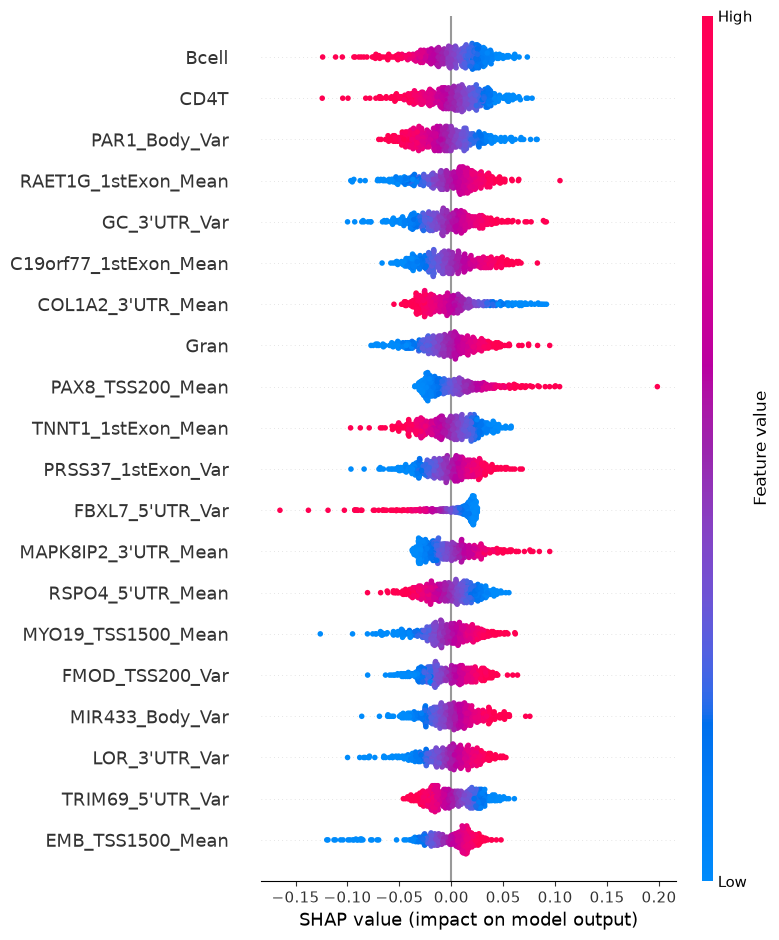

In [53]:
import shap
import json
import matplotlib.pyplot as plt

# 1. Map the 5,000 top indices back to string names (recomputed on the full dataset)
with open("/workspace/results/patient_graphs_meta.json", "r") as f:
    ordered_regions = json.load(f)["ordered_regions"]

global_variances = tensors[:, :, 0].var(dim=0)
top_5k_indices = torch.topk(global_variances, 5000).indices

hvg_names = [ordered_regions[i.item()] for i in top_5k_indices]
feature_names = (
    [f"{name}_Mean" for name in hvg_names] +
    [f"{name}_Var" for name in hvg_names] +
    ['CD8T', 'CD4T', 'NK', 'Bcell', 'Mono', 'Gran']
)

# 2. Prepare the Global Matrix (standardized, matching how the MLP was trained)
X_sub = tensors[:, top_5k_indices, :]
X_flat = X_sub.reshape(X_sub.shape[0], -1)
X_final = torch.cat([X_flat, u], dim=1)

global_mean = X_final.mean(dim=0, keepdim=True)
global_std = X_final.std(dim=0, keepdim=True)
global_std[global_std == 0] = 1e-6
X_final_scaled = (X_final - global_mean) / global_std

# 3. Train the Global Explainer Model (same architecture, full dataset)
global_model = MethylationMLP(input_dim=X_final_scaled.shape[1]).to(device)

neg_count = (y_label == 0).sum()
pos_count = (y_label == 1).sum()
pos_weight = neg_count / pos_count

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(global_model.parameters(), lr=learning_rate, weight_decay=1e-3)

global_dataset = TensorDataset(X_final_scaled, y_label.unsqueeze(1))
global_loader = DataLoader(global_dataset, batch_size=batch_size, shuffle=True)

global_model.train()
for epoch in range(epochs):
    for batch_x, batch_y in global_loader:
        optimizer.zero_grad()
        logits = global_model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()

global_model.eval()

# 4. Explain predictions with SHAP's DeepExplainer (gradient-based, works on nn.Module)
background_idx = torch.randperm(X_final_scaled.shape[0])[:100]
background = X_final_scaled[background_idx]

explainer = shap.DeepExplainer(global_model, background)
raw_shap_values = explainer.shap_values(X_final_scaled, check_additivity=False)

# 5. Intercept and format the SHAP output into a standard 2D array
if isinstance(raw_shap_values, list):
    shap_values_2d = raw_shap_values[0]
elif raw_shap_values.ndim == 3:
    shap_values_2d = raw_shap_values[:, :, 0]
else:
    shap_values_2d = raw_shap_values
shap_values_2d = np.asarray(shap_values_2d).reshape(X_final_scaled.shape[0], -1)

# 6. Generate the Beeswarm Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values_2d,
    X_final_scaled.detach().cpu().numpy(),
    feature_names=feature_names,
    max_display=20,
    plot_type="dot",
    show=False
)

save_path = "/workspace/results/peg1_MLP_shap_beeswarm.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

In [63]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch_geometric.nn import SAGEConv, global_mean_pool
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score
from safetensors.torch import load_file
import json

# 1. Define the GraphSAGE Model for Graph-Level Classification
class MethylationGraphSAGE(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels=1):
        super(MethylationGraphSAGE, self).__init__()
        
        # Message passing layers using GraphSAGE convolutions
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)
        
        # Final classifier combining graph embedding + cell proportions (6 features)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_channels + 6, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, out_channels)
        )
        
    def forward(self, x, edge_index, u, batch):
        # Step A: Graph Convolutions & Message Passing
        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = torch.relu(x)
        
        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = torch.relu(x)
        
        # Step B: Global Pooling (Aggregates node embeddings into a single graph vector per patient)
        x_graph = global_mean_pool(x, batch)  # Shape: [batch_size, hidden_channels]
        
        # Step C: Multi-modal Integration (Concatenate global graph embedding with cell proportions)
        combined = torch.cat([x_graph, u], dim=1)
        
        # Step D: Final Classification Logit
        return self.classifier(combined)

# 2. Setup Device & Load Data
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Free GPU memory left resident from earlier cells (XGBoost/MLP/SHAP) before
# loading the large per-patient tensors + 21.6M-edge graph structure below.
import gc
gc.collect()
torch.cuda.empty_cache()

# Load tensors and STRING edge structure
tensors = load_file("/workspace/results/patient_graphs.safetensors")["patient_graphs"].to(device)
with open("/workspace/results/patient_graphs_meta.json", "r") as f:
    meta = json.load(f)
    sample_ids = meta["sample_ids"]

# Assuming edge_index was saved or can be generated from your STRING adjacency matrix
edge_index = torch.load("/workspace/results/global_string_edge_index.pt", weights_only=True).to(device)

pheno_df = pd.read_parquet("/workspace/data/GSE111629_pheno_data.parquet")
if pheno_df.index.name != "Sample_Name":
    pheno_df = pheno_df.set_index("Sample_Name")
pheno_aligned = pheno_df.loc[sample_ids]

y = torch.tensor(pd.get_dummies(pheno_aligned['Sample_Group']).values.astype(np.float32), device=device)
cell_cols = ['CD8T', 'CD4T', 'NK', 'Bcell', 'Mono', 'Gran']
u = torch.tensor(pheno_aligned[cell_cols].values.astype(np.float32), device=device)
y_label = torch.argmax(y, dim=1).float()  # collapse one-hot back to a single 0/1 label

# 3. Construct PyG Data List for the Cohort
# Each patient is represented as a PyG Data object sharing the same STRING edge_index topology
# but possessing their own unique node features (e.g., raw or filtered region values).
graph_list = []
for i in range(len(sample_ids)):
    # x shape: [num_nodes, num_features_per_node]
    node_features = tensors[i] 
    patient_y = y_label[i].unsqueeze(0)
    patient_u = u[i].unsqueeze(0)
    
    data = Data(x=node_features, edge_index=edge_index, y=patient_y, u=patient_u)
    graph_list.append(data)

y_cpu = y_label.cpu().numpy()
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
epochs = 40
# batch_size=1: each graph already has ~21.6M edges (STRING PPI expanded to CpG-level
# nodes), so conv1's per-edge gather (edges * hidden_dim floats) blows past 22GB VRAM
# at larger batch sizes. Raise this only after reducing edge_index size.
batch_size = 1
learning_rate = 1e-4

roc_aucs = []
pr_aucs = []

print(f"Starting GraphSAGE 5-Fold Stratified CV on {device}...")

for fold, (train_idx, test_idx) in enumerate(skf.split(np.zeros(len(y_cpu)), y_cpu)):
    
    train_graphs = [graph_list[i] for i in train_idx]
    test_graphs = [graph_list[i] for i in test_idx]
    
    train_loader = DataLoader(train_graphs, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_graphs, batch_size=batch_size, shuffle=False)
    
    # Initialize Model, Loss, and Optimizer
    in_dim = tensors.shape[-1] # Number of features per node (e.g., mean + variance or raw tracks)
    model = MethylationGraphSAGE(in_channels=in_dim, hidden_channels=64).to(device)
    
    # Handle Class Imbalance
    train_y_vals = torch.cat([g.y for g in train_graphs])
    neg_count = (train_y_vals == 0).sum()
    pos_count = (train_y_vals == 1).sum()
    pos_weight = neg_count / pos_count
    
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-3)
    
    # Training Loop
    model.train()
    for epoch in range(epochs):
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            
            # Forward pass through GraphSAGE
            logits = model(batch.x, batch.edge_index, batch.u, batch.batch)
            loss = criterion(logits.squeeze(1), batch.y)
            
            loss.backward()
            optimizer.step()
            
    # Evaluation Loop
    model.eval()
    test_preds = []
    test_trues = []
    
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            logits = model(batch.x, batch.edge_index, batch.u, batch.batch)
            probs = torch.sigmoid(logits).squeeze(1)
            
            test_preds.extend(probs.cpu().numpy())
            test_trues.extend(batch.y.cpu().numpy())
            
    fold_roc = roc_auc_score(test_trues, test_preds)
    fold_pr = average_precision_score(test_trues, test_preds)
    
    roc_aucs.append(fold_roc)
    pr_aucs.append(fold_pr)
    
    print(f"Fold {fold+1} | ROC AUC: {fold_roc:.4f} | PR AUC: {fold_pr:.4f}")

# Final Summary
print("-" * 30)
print(f"Mean GraphSAGE ROC AUC: {np.mean(roc_aucs):.4f} ± {np.std(roc_aucs):.4f}")
print(f"Mean GraphSAGE PR AUC:  {np.mean(pr_aucs):.4f} ± {np.std(pr_aucs):.4f}")

Starting GraphSAGE 5-Fold Stratified CV on cuda...


KeyboardInterrupt: 